In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
# Load the synthetic restaurant master dataset

PROJECT_ROOT = Path.cwd().parent

RESTAURANT_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "orders"
    / "restaurants.csv"
)

restaurants = pd.read_csv(RESTAURANT_FILE)

print(f"Dataset shape: {restaurants.shape}")
print(f"Number of restaurants: {len(restaurants):,}")

restaurants.head()

Dataset shape: (220, 8)
Number of restaurants: 220


,restaurant_id,restaurant_name,zone_id,zone_name,zone_type,restaurant_category,base_popularity,average_order_value
0,Z01_R001,Express Bites 001,Z01,Kondapur,IT_Residential,Bakery,0.666,122.27
1,Z01_R002,Express House 002,Z01,Kondapur,IT_Residential,Chinese,0.571,240.27
2,Z01_R003,Grand House 003,Z01,Kondapur,IT_Residential,Bakery,0.654,248.13
3,Z01_R004,Hyderabad House 004,Z01,Kondapur,IT_Residential,Healthy Food,0.385,326.58
4,Z01_R005,Daily Kitchen 005,Z01,Kondapur,IT_Residential,Chinese,0.922,242.82


In [4]:
# Validate missing values and duplicate restaurant IDs

print("Missing values by column:")
print(restaurants.isnull().sum())

print("\nDuplicate restaurant IDs:")
print(restaurants["restaurant_id"].duplicated().sum())

print("\nUnique restaurant IDs:")
print(restaurants["restaurant_id"].nunique())

Missing values by column:
restaurant_id          0
restaurant_name        0
zone_id                0
zone_name              0
zone_type              0
restaurant_category    0
base_popularity        0
average_order_value    0
dtype: int64

Duplicate restaurant IDs:
0

Unique restaurant IDs:
220


In [5]:
# Analyze restaurant distribution across Hyderabad zones

zone_distribution = (
    restaurants
    .groupby(["zone_id", "zone_name"])
    .size()
    .reset_index(name="restaurant_count")
    .sort_values("zone_id")
)

zone_distribution

,zone_id,zone_name,restaurant_count
0,Z01,Kondapur,40
1,Z02,Hitech City,50
2,Z03,Gachibowli,45
3,Z04,Madhapur,40
4,Z05,Kukatpally,45


In [6]:
# Analyze restaurant category distribution

category_distribution = (
    restaurants["restaurant_category"]
    .value_counts()
    .sort_index()
)

category_distribution

restaurant_category
Bakery          21
Biryani         20
Burgers         20
Cafe            28
Chinese         23
Desserts        15
Fast Food       21
Healthy Food    15
North Indian    17
Pizza           20
South Indian    20
Name: count, dtype: int64

In [7]:
# Summary statistics for restaurant characteristics

restaurants[
    ["base_popularity", "average_order_value"]
].describe()

,base_popularity,average_order_value
count,220.000000,220.000000
mean,0.562650,302.030182
std,0.210805,102.900293
min,0.061000,105.420000
25%,0.399500,220.897500
50%,0.599000,290.005000
75%,0.731250,374.960000
max,0.965000,545.150000


Validate customers

In [8]:
# Load the synthetic customer master dataset

CUSTOMER_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "orders"
    / "customers.csv"
)

customers = pd.read_csv(CUSTOMER_FILE)

print(f"Dataset shape: {customers.shape}")
print(f"Number of customers: {len(customers):,}")

customers.head()

Dataset shape: (50000, 6)
Number of customers: 50,000


,customer_id,home_zone_id,home_zone_name,customer_segment,customer_activity_score,preferred_order_value
0,C000001,Z02,Hitech City,Regular,0.553,322.28
1,C000002,Z05,Kukatpally,Regular,0.473,313.17
2,C000003,Z04,Madhapur,Occasional,0.160,281.59
3,C000004,Z03,Gachibowli,Regular,0.642,392.46
4,C000005,Z01,Kondapur,Occasional,0.152,251.88


In [9]:
# Validate missing values and duplicate customer IDs

print("Missing values by column:")
print(customers.isnull().sum())

print("\nDuplicate customer IDs:")
print(customers["customer_id"].duplicated().sum())

print("\nUnique customer IDs:")
print(customers["customer_id"].nunique())

Missing values by column:
customer_id                0
home_zone_id               0
home_zone_name             0
customer_segment           0
customer_activity_score    0
preferred_order_value      0
dtype: int64

Duplicate customer IDs:
0

Unique customer IDs:
50000


In [11]:
# Analyze customer distribution across zones

customer_zone_distribution = (
    customers
    .groupby(["home_zone_id", "home_zone_name"])
    .size()
    .reset_index(name="customer_count")
    .sort_values("home_zone_id")
)

customer_zone_distribution

,home_zone_id,home_zone_name,customer_count
0,Z01,Kondapur,9010
1,Z02,Hitech City,12121
2,Z03,Gachibowli,10936
3,Z04,Madhapur,8007
4,Z05,Kukatpally,9926


In [12]:
# Analyze customer segment distribution

customer_segment_distribution = (
    customers["customer_segment"]
    .value_counts()
    .rename_axis("customer_segment")
    .reset_index(name="customer_count")
)

customer_segment_distribution

,customer_segment,customer_count
0,Occasional,22396
1,Regular,20174
2,Frequent,7430


In [13]:
# Validate customer behavioral variables

customers[
    ["customer_activity_score", "preferred_order_value"]
].describe()

,customer_activity_score,preferred_order_value
count,50000.000000,50000.000000
mean,0.428319,296.667356
std,0.249080,87.444539
min,0.050000,150.000000
25%,0.218000,227.760000
50%,0.395000,287.890000
75%,0.613000,348.070000
max,1.000000,549.930000


In [14]:
# Compare behavioral characteristics across customer segments

segment_behavior = (
    customers
    .groupby("customer_segment")[
        ["customer_activity_score", "preferred_order_value"]
    ]
    .agg(["mean", "min", "max"])
    .round(3)
)

segment_behavior

customer_activity_score             preferred_order_value  \
                                    mean   min   max                  mean   
customer_segment                                                             
Frequent                           0.849  0.70  1.00               387.178   
Occasional                         0.200  0.05  0.35               249.519   
Regular                            0.526  0.35  0.70               315.674   

                                  
                     min     max  
customer_segment                  
Frequent          220.01  549.93  
Occasional        150.00  350.00  
Regular           180.01  450.00

# Synthetic Demand Generation

The synthetic demand generation process simulates realistic hourly food-order demand across hyperlocal zones in Hyderabad.

The demand-generating process combines:

- Baseline zone demand
- Hourly seasonality
- Weekly seasonality
- Zone-specific effects
- Annual seasonal variation
- Restaurant characteristics
- Customer behavior
- Controlled demand surges
- Stochastic noise

The synthetic demand process intentionally does not use external contextual variables such as weather, rainfall, public holidays, festivals, IPL matches, or local events. These variables will be collected independently and incorporated later during contextual feature engineering.

The objective is to create a controlled synthetic demand environment that can support forecasting, surge detection, model comparison, and contextual analysis.

In [1]:
# ============================================================
# Load Synthetic Demand Generation Pipeline
# ============================================================

import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_generation.generate_demand import (
    load_master_data,
    create_hourly_timeline,
    apply_demand_patterns,
    apply_seasonal_variation,
    apply_behavioral_effects,
    add_surge_effect,
    add_stochastic_noise
)

print("Synthetic demand generation functions loaded successfully!")

Synthetic demand generation functions loaded successfully!


In [2]:
# ============================================================
# Generate Synthetic Hourly Zone-Level Demand
# ============================================================

# Load master datasets
restaurants, customers = load_master_data()

# Create hourly timeline
demand_df = create_hourly_timeline()

# Apply demand-generating components
demand_df = apply_demand_patterns(demand_df)

demand_df = apply_seasonal_variation(demand_df)

demand_df = apply_behavioral_effects(
    demand_df,
    restaurants,
    customers
)

demand_df = add_surge_effect(demand_df)

demand_df = add_stochastic_noise(demand_df)

print("Synthetic demand dataset generated successfully!")

print("\nDataset shape:")
print(demand_df.shape)

print("\nColumns:")
print(demand_df.columns.tolist())

print("\nFirst 5 records:")
display(demand_df.head())


Master data loaded successfully!
Restaurants: 220
Customers: 50,000
Synthetic demand dataset generated successfully!

Dataset shape:
(160565, 26)

Columns:
['timestamp', 'zone_id', 'date', 'hour', 'day_of_week', 'day_name', 'month', 'base_demand', 'hour_multiplier', 'day_multiplier', 'zone_multiplier', 'base_expected_demand', 'seasonal_multiplier', 'seasonal_expected_demand', 'customer_count', 'restaurant_count', 'avg_customer_activity', 'avg_restaurant_popularity', 'customer_behavior_factor', 'restaurant_effect', 'behavior_adjusted_demand', 'surge_flag', 'surge_multiplier', 'surge_adjusted_demand', 'noise_multiplier', 'realized_demand']

First 5 records:


,timestamp,zone_id,date,hour,day_of_week,day_name,month,base_demand,hour_multiplier,day_multiplier,...,avg_customer_activity,avg_restaurant_popularity,customer_behavior_factor,restaurant_effect,behavior_adjusted_demand,surge_flag,surge_multiplier,surge_adjusted_demand,noise_multiplier,realized_demand
0,2023-01-01,Z01,2023-01-01,0,6,Sunday,1,100,0.2,1.1,...,0.428648,0.530050,0.978594,1.006010,20.575542,0,1.0,20.575542,1.054791,21.702901
1,2023-01-01,Z02,2023-01-01,0,6,Sunday,1,125,0.2,1.1,...,0.431864,0.578040,0.979559,1.015608,32.488009,0,1.0,32.488009,0.987776,32.090865
2,2023-01-01,Z03,2023-01-01,0,6,Sunday,1,120,0.2,1.1,...,0.428462,0.578289,0.978538,1.015658,29.911217,0,1.0,29.911217,1.071720,32.056437
3,2023-01-01,Z04,2023-01-01,0,6,Sunday,1,105,0.2,1.1,...,0.426112,0.563725,0.977833,1.012745,23.905250,0,1.0,23.905250,1.039474,24.848876
4,2023-01-01,Z05,2023-01-01,0,6,Sunday,1,110,0.2,1.1,...,0.425315,0.557933,0.977594,1.011587,24.554130,0,1.0,24.554130,0.918835,22.561206


In [3]:
# ============================================================
# BASIC SYNTHETIC DEMAND QUALITY CHECKS
# ============================================================

print("==============================================")
print("SYNTHETIC DEMAND QUALITY CHECKS")
print("==============================================")

# ------------------------------------------------------------
# 1. Missing values
# ------------------------------------------------------------

print("\n1. Missing values:")

missing_values = demand_df.isnull().sum()

print(
    missing_values[missing_values > 0]
)

# ------------------------------------------------------------
# 2. Duplicate timestamp-zone combinations
# ------------------------------------------------------------

print("\n2. Duplicate timestamp-zone combinations:")

duplicate_count = demand_df.duplicated(
    subset=["timestamp", "zone_id"]
).sum()

print(duplicate_count)

# ------------------------------------------------------------
# 3. Unique timestamps
# ------------------------------------------------------------

print("\n3. Unique timestamps:")

print(
    demand_df["timestamp"].nunique()
)

# ------------------------------------------------------------
# 4. Unique zones
# ------------------------------------------------------------

print("\n4. Unique zones:")

print(
    demand_df["zone_id"].nunique()
)

# ------------------------------------------------------------
# 5. Negative realized demand
# ------------------------------------------------------------

print("\n5. Negative realized demand:")

print(
    (demand_df["realized_demand"] < 0).sum()
)

# ------------------------------------------------------------
# 6. Surge records
# ------------------------------------------------------------

print("\n6. Surge records:")

print(
    demand_df["surge_flag"].sum()
)

# ------------------------------------------------------------
# 7. Realized demand statistics
# ------------------------------------------------------------

print("\n7. Realized demand statistics:")

print(
    demand_df["realized_demand"].describe().round(2)
)

SYNTHETIC DEMAND QUALITY CHECKS

1. Missing values:
Series([], dtype: int64)

2. Duplicate timestamp-zone combinations:
0

3. Unique timestamps:
32113

4. Unique zones:
5

5. Negative realized demand:
0

6. Surge records:
525

7. Realized demand statistics:
count    160565.00
mean        107.05
std          76.50
min          11.06
25%          31.62
50%          93.21
75%         160.64
max         671.52
Name: realized_demand, dtype: float64


Average realized demand by hour:


,hour,realized_demand
0,0,26.87
1,1,24.20
2,2,21.50
3,3,20.14
4,4,20.14
5,5,24.18
6,6,33.58
7,7,60.41
8,8,87.23
9,9,100.63


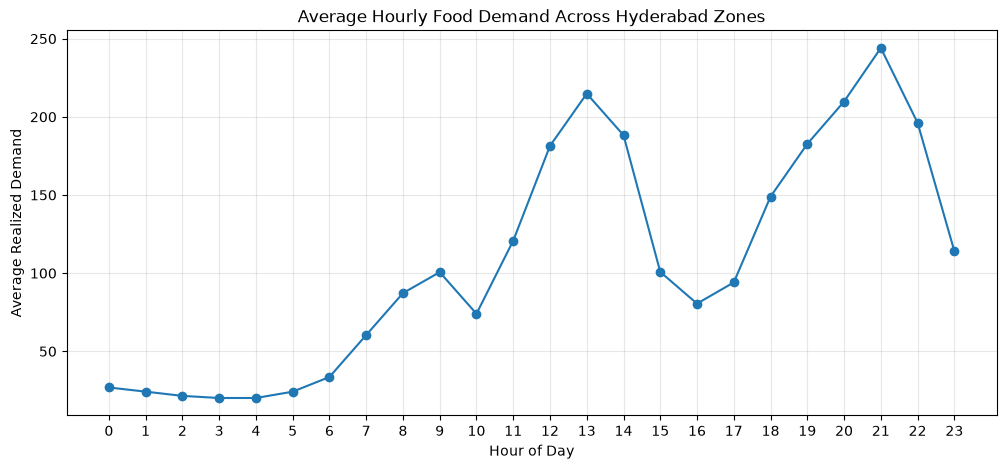

In [5]:
# ============================================================
# HOURLY DEMAND PATTERN ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# Calculate average realized demand by hour
hourly_demand = (
    demand_df
    .groupby("hour")["realized_demand"]
    .mean()
    .reset_index()
)

# Display summary
print("Average realized demand by hour:")
display(
    hourly_demand.round(2)
)

# Plot hourly demand pattern
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand["hour"],
    hourly_demand["realized_demand"],
    marker="o"
)

plt.title("Average Hourly Food Demand Across Hyderabad Zones")
plt.xlabel("Hour of Day")
plt.ylabel("Average Realized Demand")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

Average realized demand by day of week:


,day_of_week,day_name,realized_demand
0,0,Monday,91.12
1,1,Tuesday,96.28
2,2,Wednesday,101.29
3,3,Thursday,106.23
4,4,Friday,116.28
5,5,Saturday,126.59
6,6,Sunday,111.56


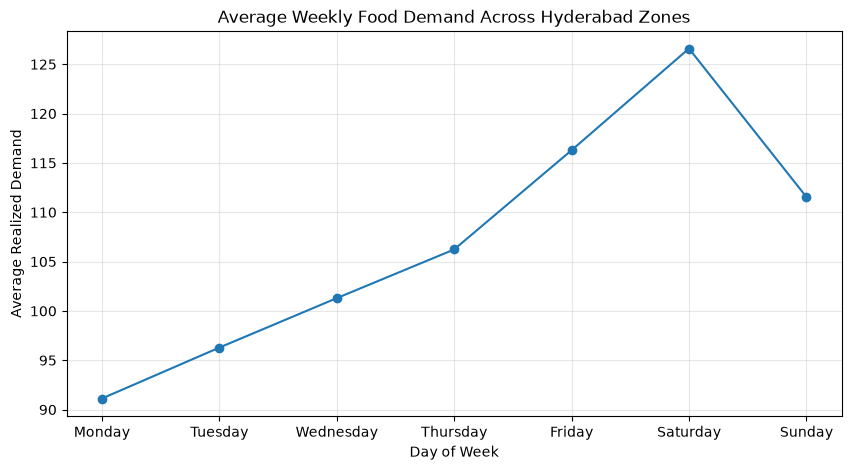

In [6]:
# ============================================================
# WEEKLY DEMAND PATTERN ANALYSIS
# ============================================================

# Calculate average realized demand by day of week
weekly_demand = (
    demand_df
    .groupby(["day_of_week", "day_name"])["realized_demand"]
    .mean()
    .reset_index()
    .sort_values("day_of_week")
)

# Display summary
print("Average realized demand by day of week:")

display(
    weekly_demand.round(2)
)

# Plot weekly demand pattern
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_demand["day_name"],
    weekly_demand["realized_demand"],
    marker="o"
)

plt.title("Average Weekly Food Demand Across Hyderabad Zones")
plt.xlabel("Day of Week")
plt.ylabel("Average Realized Demand")
plt.grid(True, alpha=0.3)

plt.show()

Average realized demand by zone:


,zone_id,zone_name,realized_demand
1,Z02,Hitech City,132.35
2,Z03,Gachibowli,121.79
4,Z05,Kukatpally,99.94
3,Z04,Madhapur,97.40
0,Z01,Kondapur,83.78


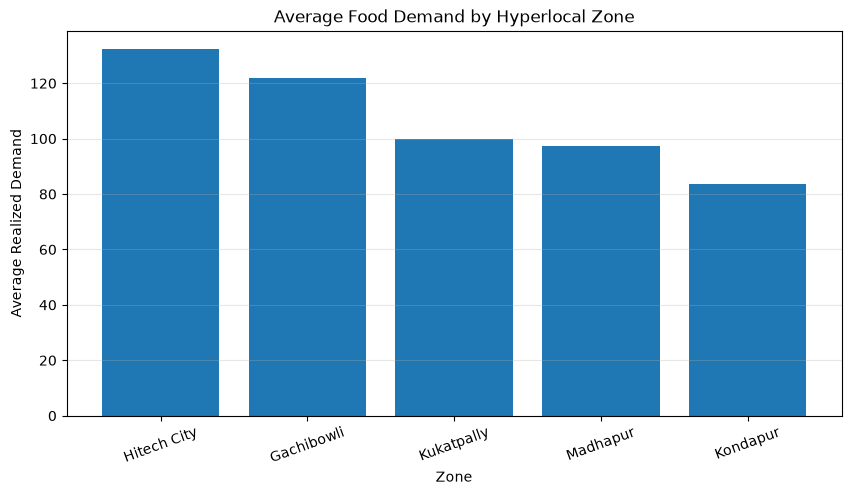

In [7]:
# ============================================================
# ZONE-LEVEL DEMAND ANALYSIS
# ============================================================

# Calculate average realized demand by zone
zone_demand = (
    demand_df
    .groupby(["zone_id"])["realized_demand"]
    .mean()
    .reset_index()
)

# Add zone names
zone_names = {
    "Z01": "Kondapur",
    "Z02": "Hitech City",
    "Z03": "Gachibowli",
    "Z04": "Madhapur",
    "Z05": "Kukatpally"
}

zone_demand["zone_name"] = zone_demand["zone_id"].map(
    zone_names
)

zone_demand = zone_demand[
    ["zone_id", "zone_name", "realized_demand"]
]

# Sort by demand
zone_demand = zone_demand.sort_values(
    "realized_demand",
    ascending=False
)

print("Average realized demand by zone:")

display(
    zone_demand.round(2)
)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    zone_demand["zone_name"],
    zone_demand["realized_demand"]
)

plt.title("Average Food Demand by Hyperlocal Zone")
plt.xlabel("Zone")
plt.ylabel("Average Realized Demand")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

Average realized demand by month:


,month,realized_demand,month_name
0,1,100.41,January
1,2,103.86,February
2,3,106.01,March
3,4,101.58,April
4,5,97.78,May
5,6,103.89,June
6,7,105.57,July
7,8,108.66,August
8,9,111.32,September
9,10,114.03,October


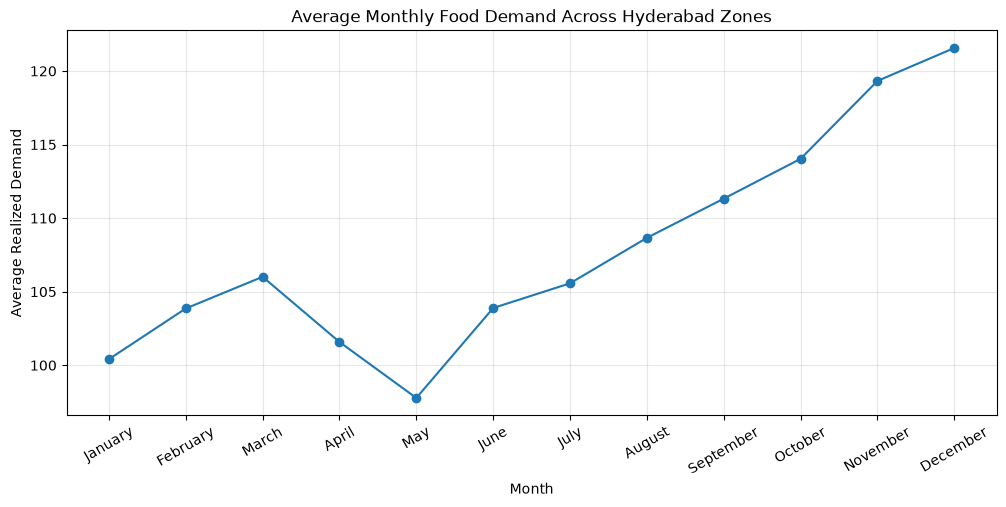

In [8]:
# ============================================================
# MONTHLY SEASONAL DEMAND ANALYSIS
# ============================================================

# Calculate average realized demand by month
monthly_demand = (
    demand_df
    .groupby("month")["realized_demand"]
    .mean()
    .reset_index()
)

# Month names
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_demand["month_name"] = monthly_demand["month"].map(
    month_names
)

print("Average realized demand by month:")

display(
    monthly_demand.round(2)
)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["month_name"],
    monthly_demand["realized_demand"],
    marker="o"
)

plt.title("Average Monthly Food Demand Across Hyderabad Zones")
plt.xlabel("Month")
plt.ylabel("Average Realized Demand")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)

plt.show()

Surge vs Normal Demand Summary:


,Demand Type,Observation Count,Average Demand,Maximum Demand
0,Normal,160040,106.44,425.19
1,Surge,525,294.12,671.52



Surge multiplier summary:


,surge_multiplier
count,525.000
mean,1.494
std,0.172
min,1.200
25%,1.336
50%,1.504
75%,1.639
max,1.797


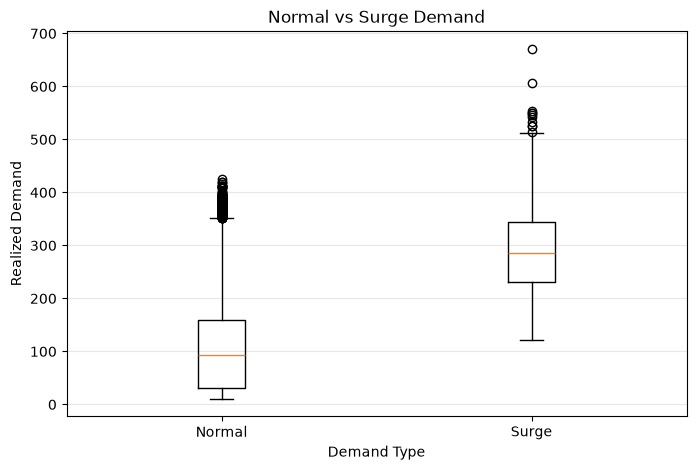

In [12]:
# ============================================================
# SURGE VS NORMAL DEMAND ANALYSIS
# ============================================================
import pandas as pd
# Separate normal and surge observations
normal_demand = demand_df[
    demand_df["surge_flag"] == 0
]

surge_demand = demand_df[
    demand_df["surge_flag"] == 1
]

# Calculate summary statistics
surge_summary = pd.DataFrame({
    "Demand Type": [
        "Normal",
        "Surge"
    ],
    "Observation Count": [
        len(normal_demand),
        len(surge_demand)
    ],
    "Average Demand": [
        normal_demand["realized_demand"].mean(),
        surge_demand["realized_demand"].mean()
    ],
    "Maximum Demand": [
        normal_demand["realized_demand"].max(),
        surge_demand["realized_demand"].max()
    ]
})

print("Surge vs Normal Demand Summary:")

display(
    surge_summary.round(2)
)

# ============================================================
# SURGE MULTIPLIER SUMMARY
# ============================================================

print("\nSurge multiplier summary:")

display(
    demand_df.loc[
        demand_df["surge_flag"] == 1,
        "surge_multiplier"
    ]
    .describe()
    .round(3)
    .to_frame()
)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        normal_demand["realized_demand"],
        surge_demand["realized_demand"]
    ],
    tick_labels=["Normal", "Surge"]
)

plt.title("Normal vs Surge Demand")
plt.xlabel("Demand Type")
plt.ylabel("Realized Demand")
plt.grid(axis="y", alpha=0.3)

plt.show()

Stochastic noise multiplier statistics:


,noise_multiplier
count,160565.0000
mean,1.0001
std,0.0577
min,0.9000
25%,0.9500
50%,1.0003
75%,1.0501
max,1.1000



Mean noise multiplier:
1.0001

Noise range:
Minimum: 0.9
Maximum: 1.1


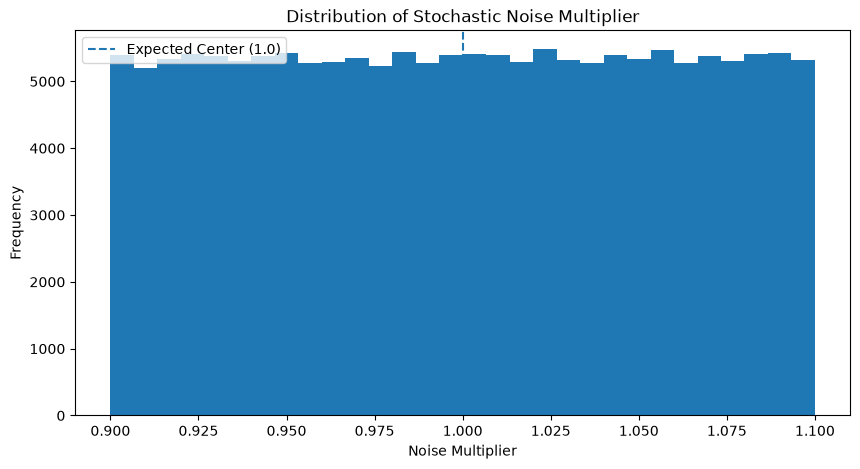

In [13]:
# ============================================================
# STOCHASTIC NOISE ANALYSIS
# ============================================================

noise_summary = demand_df["noise_multiplier"].describe()

print("Stochastic noise multiplier statistics:")

display(
    noise_summary.round(4).to_frame()
)

# Check whether noise is centered around 1.0
mean_noise = demand_df["noise_multiplier"].mean()

print("\nMean noise multiplier:")
print(round(mean_noise, 4))

print("\nNoise range:")

print(
    "Minimum:",
    round(demand_df["noise_multiplier"].min(), 4)
)

print(
    "Maximum:",
    round(demand_df["noise_multiplier"].max(), 4)
)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    demand_df["noise_multiplier"],
    bins=30
)

plt.axvline(
    1.0,
    linestyle="--",
    label="Expected Center (1.0)"
)

plt.title("Distribution of Stochastic Noise Multiplier")
plt.xlabel("Noise Multiplier")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# Synthetic Demand Generation — Summary

The synthetic demand generation stage successfully produced an hourly zone-level demand dataset for five hyperlocal zones in Hyderabad.

The demand-generating process combines:

- Baseline demand
- Hourly demand patterns
- Weekly seasonality
- Zone-specific demand effects
- Monthly seasonal variation
- Restaurant-level characteristics
- Customer behavioral effects
- Controlled demand surges
- Stochastic noise

The generated dataset contains 160,565 hourly zone-level observations covering the study period from January 2023 to August 2026.

Quality validation confirmed:

- No missing values
- No duplicate timestamp-zone combinations
- Five unique hyperlocal zones
- Positive realized demand values
- Controlled surge observations
- Stochastic noise centered approximately around 1.0

Exploratory analysis confirmed distinct intraday, weekly, monthly, and zone-level demand patterns.

The synthetic demand process intentionally excludes external contextual variables such as weather, rainfall, public holidays, festivals, IPL matches, and local events. These variables will be collected independently and incorporated later during contextual feature engineering.

The validated demand signal will next be converted into transaction-level food orders for the raw synthetic order dataset.